In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import imprl.envs

sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.25,
    font="Times New Roman",
)

## k-out-of-n infinite horizon

In [2]:
# Load data
results_summary_df = pd.read_csv("./data/results_summary.csv")
results_evals_df = pd.read_csv("./data/results_evals.csv")

ENV_NAME = "k_out_of_n_infinite"
SETTINGS = [f"hard-{k}-of-4_infinite" for k in range(1, 5)]
SETTING_NAMES = [f"{k}-out-of-4" for k in range(1, 5)]

ALGORITHM_META = {
    "DDQN": {"paradigm": "CTCE (POMDP)", "name": "DDQN"},
    "JAC": {"paradigm": "CTCE (POMDP)", "name": "JAC"},
    "DCMAC": {"paradigm": "CTCE (MPOMDP)", "name": "DCMAC"},
    "IACC_PS": {"paradigm": "CTDE (Dec-POMDP)", "name": "IACC-PS"},
    "MAPPO_PS": {"paradigm": "CTDE (Dec-POMDP)", "name": "MAPPO-PS"},
    "QMIX_PS": {"paradigm": "CTDE (Dec-POMDP)", "name": "QMIX-PS"},
    "VDN_PS": {"paradigm": "CTDE (Dec-POMDP)", "name": "VDN-PS"},
    "IAC_PS": {"paradigm": "DTDE (Dec-POMDP)", "name": "IAC-PS"},
    "IPPO_PS": {"paradigm": "DTDE (Dec-POMDP)", "name": "IPPO-PS"},
}

ALGORITHMS = list(ALGORITHM_META.keys())
ALGORITHM_NAMES = [ALGORITHM_META[a]["name"] for a in ALGORITHMS]

RANDOM_SEEDS = 10

BASELINES = {}
for setting in SETTINGS:
    env = imprl.envs.make(ENV_NAME, setting)
    BASELINES[setting] = env.core.baselines

# assert that there are RANDOM_SEEDS unique run ids per algorithm-setting pair
for alg in ALGORITHM_META.keys():
    for setting in SETTINGS:
        # Results summary
        subset = results_summary_df[
            (results_summary_df["algorithm"] == alg)
            & (results_summary_df["setting"] == setting)
        ]
        unique_run_ids = subset["run_id"].nunique()
        assert (
            unique_run_ids == RANDOM_SEEDS
        ), f"Algorithm {alg} in setting {setting} has {unique_run_ids} unique run ids, expected {RANDOM_SEEDS}"

# Price of Decentralization vs Redundancy

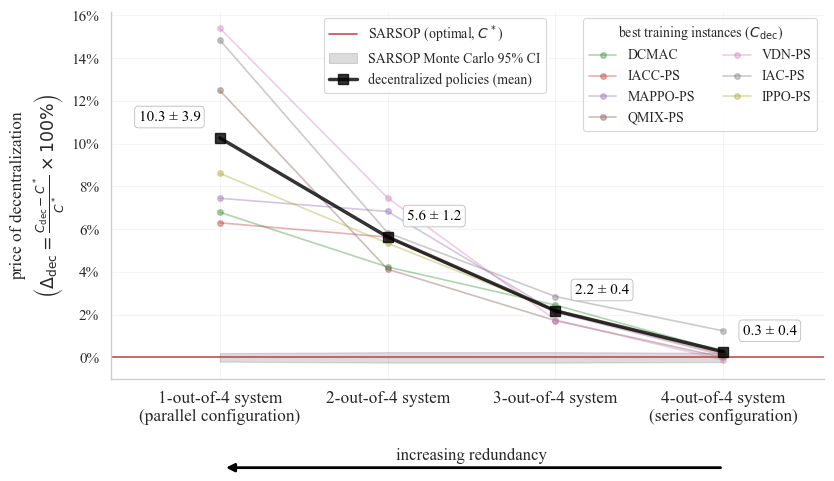

In [3]:
# --------------------------------------------------------------------------- #
# Price of decentralization vs redundancy: normalized cost regret of the
# multi-agent algorithms (excl. DDQN, JAC) vs redundancy. Thin per-algorithm
# lines, one thick mean line, mean+/-std callouts, compact legend.
#  * x axis: parallel (most redundant) on the left, series (no redundancy) on
#    the right, matching the boxplot figure's axis order and arrow direction.
#  * colours are the EXACT hex rendered in the boxplot figure below
#    (tab10 @ alpha=0.9 over white), so the two figures match on the page.
# --------------------------------------------------------------------------- #
from matplotlib.ticker import PercentFormatter

DEC_ALGS = [a for a in ALGORITHMS if a not in ("DDQN", "JAC")]
DEC_ALGS_NAMES = {a: ALGORITHM_META[a]["name"] for a in DEC_ALGS}
# Exact hex rendered in the boxplot figure below (tab10 @ alpha=0.9 over
# white), extracted directly from that figure's patches.
ALG_COLORS = {
    "DDQN": "#3274a1",
    "JAC": "#e1812c",
    "DCMAC": "#3a923a",
    "IACC_PS": "#c03d3e",
    "MAPPO_PS": "#9372b2",
    "QMIX_PS": "#845b53",
    "VDN_PS": "#d684bd",
    "IAC_PS": "#7f7f7f",
    "IPPO_PS": "#a9aa35",
}

PLOT_ALGS = [a for a in DEC_ALGS_NAMES if a in results_summary_df.algorithm.unique()]

best = results_summary_df.loc[
    results_summary_df.groupby(["setting", "algorithm"])["best_cost"].idxmin()
]
kn = best[best.setting.isin(SETTINGS)]
regret = kn.pivot_table(
    index="algorithm", columns="setting", values="normalized_best_cost"
)
regret = regret[SETTINGS] * 100  # Delta_dec, percent

# parallel (1-of-4) on the LEFT -> series (4-of-4) on the RIGHT.
xpos = np.arange(len(SETTINGS))
config_tag = {1: "parallel configuration", 4: "series configuration"}
xlabels = [
    f"{k}-out-of-4 system" + (f"\n({config_tag[k]})" if k in config_tag else "")
    for k in range(1, len(SETTINGS) + 1)
]

fig, ax = plt.subplots(figsize=(8.5, 5))

# Light per-algorithm lines (detail layer).
for alg in PLOT_ALGS:
    ax.plot(
        xpos,
        regret.loc[alg, SETTINGS].values,
        marker="o",
        markersize=4,
        lw=1.2,
        ls="-",
        alpha=0.4,
        color=ALG_COLORS[alg],
        label=DEC_ALGS_NAMES[alg],
    )

# Thick summary line: mean over all decentralized policies.
dec_mean = regret.loc[PLOT_ALGS, SETTINGS].mean(axis=0).values
ax.plot(
    xpos,
    dec_mean,
    marker="s",
    markersize=7,
    lw=2.5,
    ls="-",
    color="black",
    alpha=0.8,
    zorder=5,
    label="decentralized policies (mean)",
)

# Annotate the summary line with mean +/- std, up-right of each marker --
# except the first point, which sits right under the legend AND right where
# the per-algorithm lines fan out to its right. Nothing is plotted to the
# LEFT of x=0 at all, so that label goes up-left instead, into the empty
# margin before the lines start.
dec_std = regret.loc[PLOT_ALGS, SETTINGS].std(axis=0).values
for i, (x, m, s) in enumerate(zip(xpos, dec_mean, dec_std)):
    is_first = i == 0
    ax.annotate(
        f"{m:.1f} \u00b1 {s:.1f}",
        (x, m),
        textcoords="offset points",
        xytext=(-14, 10) if is_first else (14, 10),
        ha="right" if is_first else "left",
        va="bottom",
        fontsize=11,
        color="black",
        zorder=6,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", lw=0.6, alpha=0.9),
    )

ax.axhline(0, color="r", label=r"SARSOP (optimal, $C^*$)")

# SARSOP Monte Carlo 95% CI, relative to its own mean (so it is centered on
# the zero line), per setting -- same source as the boxplot figure's SARSOP
# band.
sarsop_lo, sarsop_hi = [], []
for s in SETTINGS:
    _sarsop = BASELINES[s]["SARSOP"]
    _mean = _sarsop["mean"]
    _lo, _hi = _sarsop["95_ci"]
    sarsop_lo.append((_lo / _mean - 1) * 100)
    sarsop_hi.append((_hi / _mean - 1) * 100)
# NOTE: matplotlib hatch spacing is fixed regardless of patch size, so a
# hatch pattern cannot render as visible diagonal lines on a band this thin
# (~0.5 percentage points here vs. the boxplot figure's much taller CI
# bands) -- it just collapses into a solid smear. A plain light fill reads
# correctly at this scale instead.
ax.fill_between(
    xpos,
    sarsop_lo,
    sarsop_hi,
    color="k",
    alpha=0.15,
    zorder=1,
    label="SARSOP Monte Carlo 95% CI",
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xticks(xpos)
ax.set_xticklabels(xlabels, fontsize=12.5)
ax.set_xlim(-0.65, len(SETTINGS) - 0.4)  # extra left margin for the first
# point's annotation, which sits to the left of x=0
ax.set_ylabel(
    r"price of decentralization"
    + "\n"
    + r"$\left( \Delta_{\mathrm{dec}} = \frac{C_{\text{dec}} - C^*}{C^*} \times 100\% \right)$",
    fontsize=12.5,
)

# Legend, split into two boxes side by side: a single reference column
# (SARSOP, its CI, the mean line) plus a titled block of the per-algorithm
# best-instance lines, so "best training instances" reads as a caption over
# just those entries rather than the whole legend.
handles, labels = ax.get_legend_handles_labels()
_ref_labels = [
    "SARSOP (optimal, $C^*$)",
    "SARSOP Monte Carlo 95% CI",
    "decentralized policies (mean)",
]
_ref_idx = [labels.index(l) for l in _ref_labels]
_alg_idx = [i for i in range(len(labels)) if i not in _ref_idx]

_alg_legend = ax.legend(
    [handles[i] for i in _alg_idx],
    [labels[i] for i in _alg_idx],
    title=r"best training instances ($C_{\mathrm{dec}}$)",
    frameon=True,
    ncol=2,
    fontsize=10,
    title_fontsize=10,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),
)
ax.add_artist(_alg_legend)
ax.legend(
    [handles[i] for i in _ref_idx],
    [labels[i] for i in _ref_idx],
    frameon=True,
    ncol=1,
    fontsize=10,
    loc="upper right",
    bbox_to_anchor=(0.62, 1.0),
)

# --- Redundancy arrow below, pointing LEFT (matches the boxplot figure);
# label text stays above the arrow. ---
_arrow_y = -0.24
ax.text(
    (len(SETTINGS) - 1) / 2,
    _arrow_y + 0.01,
    "increasing redundancy",
    transform=ax.get_xaxis_transform(),
    fontsize=12,
    ha="center",
    va="bottom",
)
ax.annotate(
    "",
    xy=(0.02, _arrow_y),
    xytext=(len(SETTINGS) - 1, _arrow_y),
    xycoords=ax.get_xaxis_transform(),
    textcoords=ax.get_xaxis_transform(),
    arrowprops=dict(arrowstyle="-|>", color="black", lw=2, alpha=1),
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig("./figures/pod_vs_redundancy.pdf", bbox_inches="tight")
plt.show()

# Box Plots

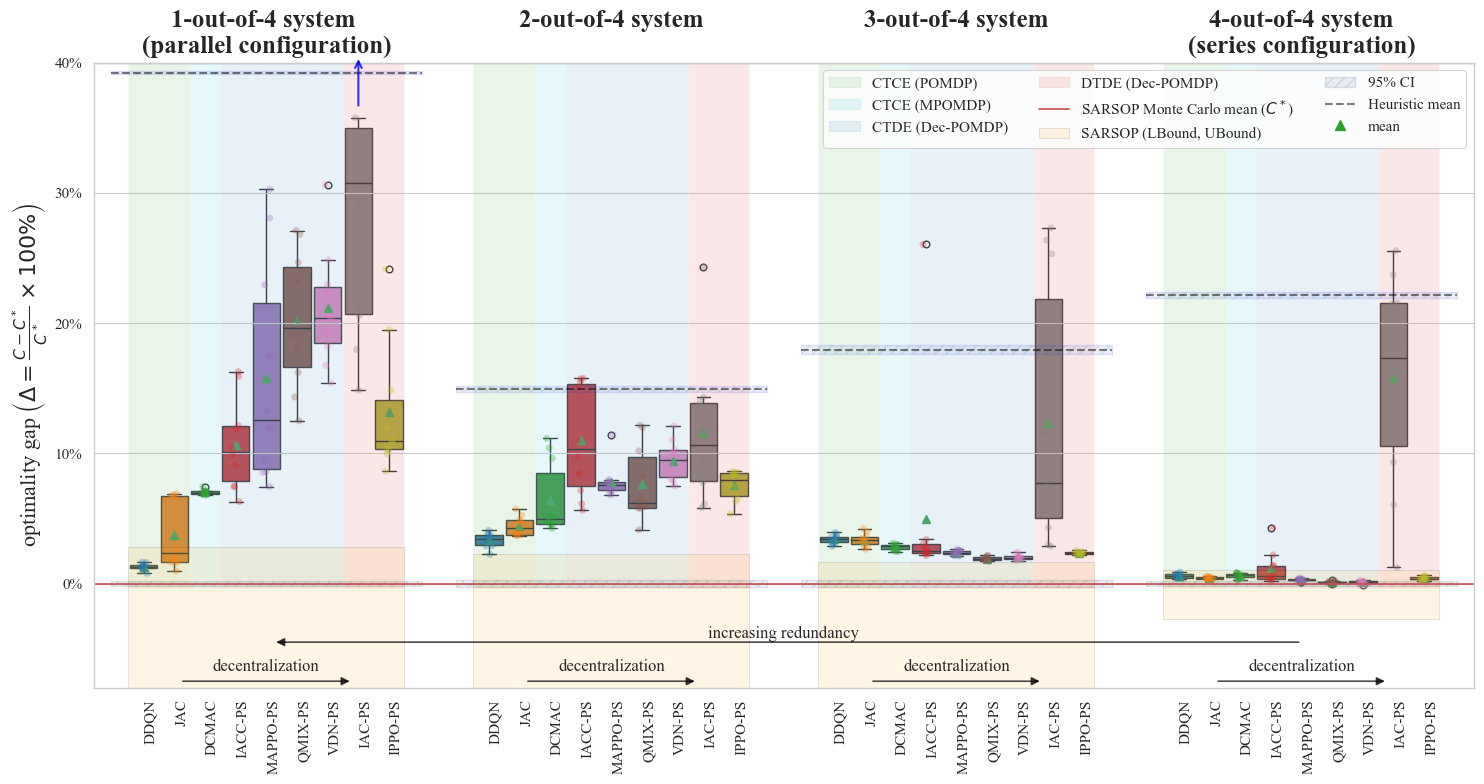

In [4]:
# Subset data to only k-out-of-n infinite results
results_subset_df = results_summary_df[
    results_summary_df["algorithm"].isin(ALGORITHMS)
    & results_summary_df["setting"].isin(SETTINGS)
].copy()

# Percent scale, aligned with the paper's definition of the price of
# decentralization: Delta_dec := (C - C*)/C* x 100%.
results_subset_df["normalized_best_cost"] *= 100

# Derive paradigm ordering and colors from ALGORITHM_META
from itertools import groupby, cycle
from matplotlib.ticker import PercentFormatter

PARADIGMS = [ALGORITHM_META[a]["paradigm"] for a in ALGORITHMS]
PARADIGM_ORDER = list(dict.fromkeys(PARADIGMS))
PARADIGM_RUNS = [(p, sum(1 for _ in g)) for p, g in groupby(PARADIGMS)]

_default_paradigm_colors = {
    "CTCE (POMDP)": "tab:green",
    "CTCE (MPOMDP)": "tab:cyan",
    "CTDE (Dec-POMDP)": "tab:blue",
    "DTDE (Dec-POMDP)": "tab:red",
}
PARADIGM_COLORS = {p: _default_paradigm_colors.get(p) for p in PARADIGM_ORDER}
_color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])
for p in PARADIGM_ORDER:
    if PARADIGM_COLORS[p] is None:
        PARADIGM_COLORS[p] = next(_color_cycle)

# Grouped box + strip plot per setting, with baseline bands and config shading
fig, ax = plt.subplots(figsize=(15, 8))
ax.grid(axis="x", linestyle="-", alpha=0.01)

_patch_alpha = 0.1
ymin, ymax = 0.16, 1.0

# --- Shade paradigm regions per setting on the x axis ---
for s in range(len(SETTINGS)):
    left = -0.4 + s
    per_alg_width = 0.8 / len(ALGORITHMS)
    for paradigm, count in PARADIGM_RUNS:
        right = left + count * per_alg_width
        ax.axvspan(
            left,
            right,
            ymin,
            ymax,
            facecolor=PARADIGM_COLORS[paradigm],
            alpha=_patch_alpha,
        )
        left = right

# --- Boxplot + stripplot per setting and algorithm ---
sns.boxplot(
    data=results_subset_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    hue_order=ALGORITHMS,
    palette="tab10",
    showmeans=True,
    linewidth=1,
    gap=0.1,
    zorder=0,
    legend=False,
    boxprops=dict(alpha=0.9),
)

sns.stripplot(
    data=results_subset_df,
    ax=ax,
    x="setting",
    y="normalized_best_cost",
    hue="algorithm",
    hue_order=ALGORITHMS,
    palette="tab10",
    dodge=True,
    alpha=0.3,
    jitter=0.1,
    zorder=2,
    legend=False,
)

# --- Relabel x axis to show algorithms instead of settings ---
all_patches = [p for p in ax.patches if isinstance(p, matplotlib.patches.PathPatch)]

# Seaborn draws boxes grouped by x then hue
_positions = []
for patch in all_patches:
    verts = patch.get_path().vertices
    box_x = verts[0:2, 0].mean()  # left and right x coords
    _positions.append(box_x)
_positions = sorted(_positions)

_labels = ALGORITHM_NAMES * len(SETTINGS)
ax.set_xticks(_positions)
ax.set_xticklabels(_labels, rotation=90, ha="left")
ax.set_xlabel(None)

# --- Baseline: SARSOP horizontal line at zero (normalized) ---
ax.axhline(y=0.0, color="r", linestyle="-", label=r"SARSOP Monte Carlo mean ($C^*$)")

ax.set_xlim(-0.5, len(SETTINGS) - 0.5)
ax.set_ylim(-8, 40)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

# Shared style for every directional arrow in this figure (overflow
# markers, the per-setting "decentralization" arrows, the "increasing
# redundancy" arrow) -- one place to edit/comment on, instead of the same
# arrowprops dict repeated at each call site.
ARROW_STYLE = dict(arrowstyle="-|>", color="black", lw=1.2, alpha=0.7)

# Indicate distributions extending beyond the top y-limit.
y_top = ax.get_ylim()[1]
num_algs = len(ALGORITHMS)
max_by_pair = results_subset_df.groupby(["setting", "algorithm"], observed=False)[
    "normalized_best_cost"
].max()
for s_idx, setting in enumerate(SETTINGS):
    for a_idx, alg in enumerate(ALGORITHMS):
        max_val = max_by_pair.get((setting, alg), np.nan)
        if pd.notna(max_val) and max_val > y_top:
            x_idx = s_idx * num_algs + a_idx
            if x_idx < len(_positions):
                x_pos = _positions[x_idx]
                ax.annotate(
                    "",
                    xy=(x_pos, y_top + 0.5),
                    xytext=(x_pos, y_top - 3.5),
                    arrowprops=dict(arrowstyle="->", color="blue", lw=1.5, alpha=0.8),
                    clip_on=False,
                    annotation_clip=False,
                    zorder=5,
                )

ax.set_ylabel(
    r"optimality gap $\left( \Delta = \frac{C - C^*}{C^*} \times 100\% \right)$",
    fontsize=16,
)

# --- Baselines per setting: intervals and heuristic ---
for s, setting in enumerate(SETTINGS):
    _sarsop = BASELINES[setting]["SARSOP"]
    baseline = _sarsop["mean"]
    LBound, UBound = _sarsop["LBound"], _sarsop["UBound"]
    rel_LBound = (LBound / baseline - 1) * 100
    rel_UBound = (UBound / baseline - 1) * 100

    # SARSOP lower–upper bound band
    ax.fill_between(
        [s - 0.4, s + 0.4],
        rel_LBound,
        rel_UBound,
        color="orange",
        alpha=0.1,
        edgecolor="black",
        label="SARSOP (LBound, UBound)" if s == 0 else None,
    )

    # SARSOP MC 95 percent CI band
    MC_mean, MC_95_ci = _sarsop["mean"], _sarsop["95_ci"]
    MC_lower = (MC_95_ci[0] / baseline - 1) * 100
    MC_upper = (MC_95_ci[1] / baseline - 1) * 100
    ax.fill_between(
        [s - 0.45, s + 0.45],
        MC_lower,
        MC_upper,
        color=None,
        alpha=0.1,
        edgecolor="black",
        hatch="///",
        linewidth=1,
        label="95% CI" if s == 0 else None,
    )

    # Inspect–repair heuristic mean + CI
    _heuristic = BASELINES[setting]["InspectRepair"]
    H_mean, H_95_ci = _heuristic["mean"], _heuristic["95_ci"]
    H_lower = (H_95_ci[0] / baseline - 1) * 100
    H_upper = (H_95_ci[1] / baseline - 1) * 100

    ax.hlines(
        y=(H_mean / baseline - 1) * 100,
        xmin=s - 0.45,
        xmax=s + 0.45,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Heuristic mean" if s == 0 else None,
    )
    ax.fill_between(
        [s - 0.45, s + 0.45],
        H_lower,
        H_upper,
        color=None,
        alpha=0.1,
        edgecolor="blue",
        hatch="///",
        linewidth=1,
        # label="Heuristic 95% CI" if s == 0 else None,
    )

    # draw small arrows from left to right indicating decentralization direction
    ax.text(
        s,
        -7.0,
        "decentralization",
        fontsize=12,
        ha="center",
        va="bottom",
    )
    ax.annotate(
        "",
        xy=(s + 0.25, -7.5),
        xytext=(s - 0.25, -7.5),
        arrowprops=ARROW_STYLE,
    )

# --- Redundancay arrow below ---
_top_arrow_y = -4.5
ax.text(
    len(SETTINGS) / 2 - 0.5,
    _top_arrow_y + 0.005,
    "increasing redundancy",
    fontsize=12,
    ha="center",
    va="bottom",
)
ax.annotate(
    "",
    xy=(0.02, _top_arrow_y),
    xytext=(len(SETTINGS) - 1, _top_arrow_y),
    arrowprops=ARROW_STYLE,
)

# --- Secondary x axis showing k-out-of-n setting names ---
secax = ax.secondary_xaxis("top")
secax.set_xticks(np.arange(len(SETTINGS)))
_names = [
    "1-out-of-4 system \n(parallel configuration)",
    "2-out-of-4 system\n",
    "3-out-of-4 system\n",
    "4-out-of-4 system\n(series configuration)",
]
secax.set_xticklabels(_names, fontsize=18, fontdict={"weight": "bold"})
secax.tick_params(axis="x", which="both", length=0)

# --- Legend: shading types + algorithms + means ---
paradigm_handles = [
    Patch(color=PARADIGM_COLORS[p], alpha=_patch_alpha, label=p)
    for p in PARADIGM_ORDER
]

# Auto items from seaborn (boxes, points, baselines, etc.)
auto_handles, auto_labels = ax.get_legend_handles_labels()

# Extra marker to show the boxplot mean symbol in the legend
mean_marker = Line2D(
    [0],
    [0],
    color="tab:green",
    marker="^",
    linestyle="None",
    markersize=5,
    label="mean",
)

all_handles = [
    *paradigm_handles,
    *auto_handles,
    mean_marker,
]
all_labels = [h.get_label() for h in all_handles]

# Remove duplicate labels while preserving order
unique = {}
for lbl, h in zip(all_labels, all_handles):
    if lbl not in unique and lbl != "":
        unique[lbl] = h

ax.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    ncol=3,
    markerscale=1.5,
)

plt.tight_layout()
fig_name = "boxplot_kn_infinite"
plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)
plt.show()

# Learning Curves

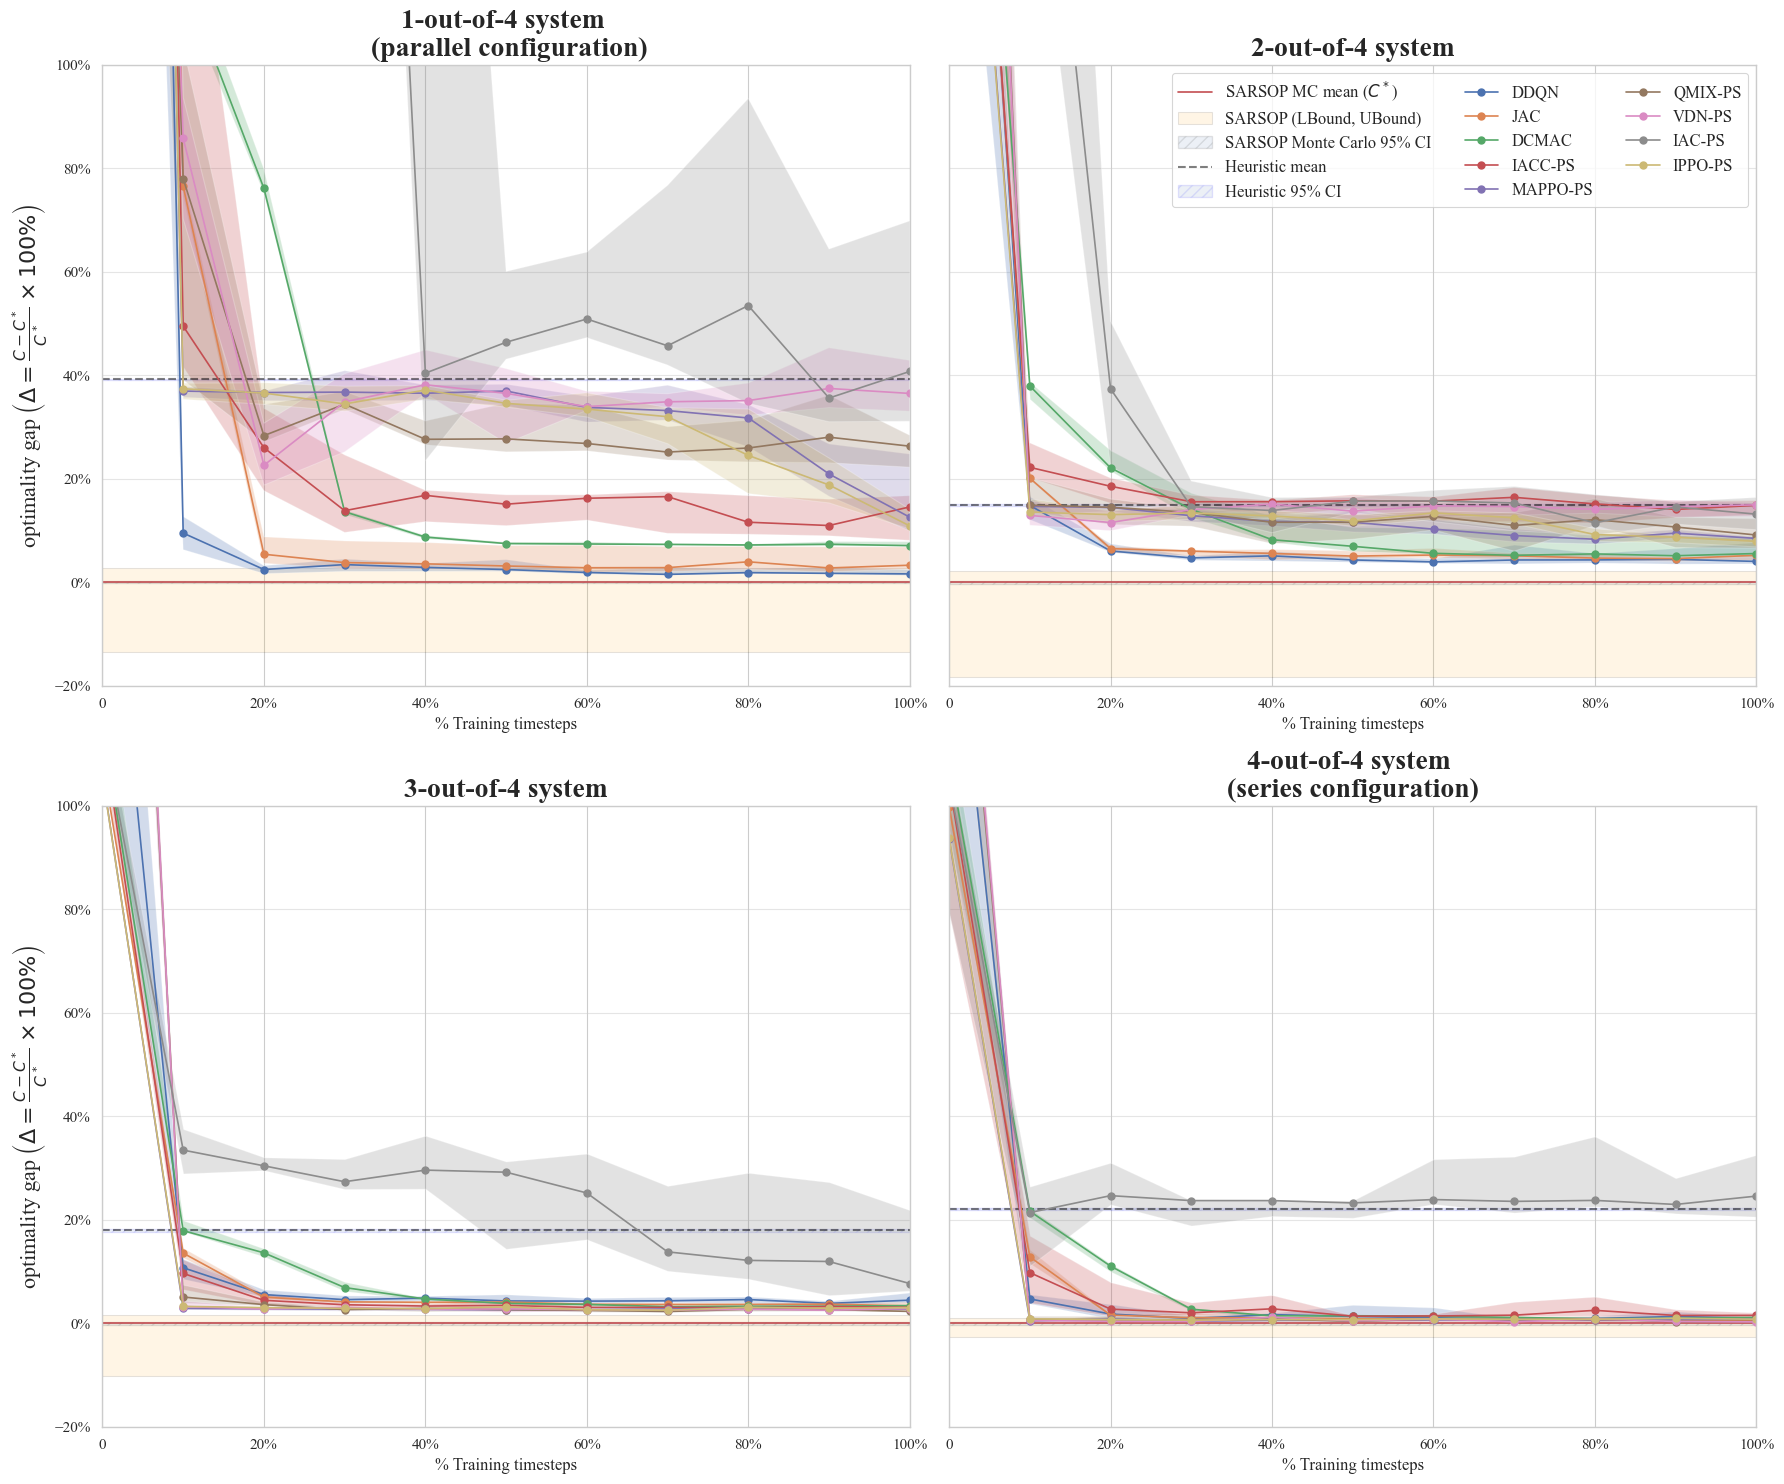

In [5]:
from matplotlib.ticker import PercentFormatter

ALG_LABEL_MAP = dict(zip(ALGORITHMS, ALGORITHM_NAMES))

fig, _ax = plt.subplots(2, 2, figsize=(18, 15), sharey=True)

for i, ax in enumerate(_ax.ravel()):
    setting_key = SETTINGS[i]  # "hard-k-of-4_infinite"
    setting_name = SETTING_NAMES[i]  # "k-out-of-4"

    # --- SARSOP baseline and bounds (normalized) ---
    sarsop = BASELINES[setting_key]["SARSOP"]
    sarsop_mean = sarsop["mean"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]

    rel_LBound = (LBound / sarsop_mean - 1) * 100
    rel_UBound = (UBound / sarsop_mean - 1) * 100

    ax.axhline(y=0.0, color="r", linestyle="-", label=r"SARSOP MC mean ($C^*$)")
    ax.fill_between(
        [0.0, 1.0],
        rel_LBound,
        rel_UBound,
        color="orange",
        alpha=0.1,
        edgecolor="black",
        label="SARSOP (LBound, UBound)",
    )

    # SARSOP Monte Carlo 95% CI
    MC_95_ci = sarsop["95_ci"]
    MC_lower = (MC_95_ci[0] / sarsop_mean - 1) * 100
    MC_upper = (MC_95_ci[1] / sarsop_mean - 1) * 100
    ax.fill_between(
        [0.0, 1.0],
        MC_lower,
        MC_upper,
        color=None,
        alpha=0.1,
        edgecolor="black",
        hatch="///",
        linewidth=1,
        label="SARSOP Monte Carlo 95% CI",
    )

    # --- Inspect–repair heuristic baseline (normalized) ---
    heur = BASELINES[setting_key]["InspectRepair"]
    H_mean, H_95_ci = heur["mean"], heur["95_ci"]
    H_lower = (H_95_ci[0] / sarsop_mean - 1) * 100
    H_upper = (H_95_ci[1] / sarsop_mean - 1) * 100

    ax.hlines(
        y=(H_mean / sarsop_mean - 1) * 100,
        xmin=0.0,
        xmax=1.0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Heuristic mean",
    )
    ax.fill_between(
        [0.0, 1.0],
        H_lower,
        H_upper,
        color=None,
        alpha=0.1,
        edgecolor="blue",
        hatch="///",
        linewidth=1,
        label="Heuristic 95% CI",
    )

    # --- Learning curves: all checkpoints, per algorithm 0–100 percent ---
    data_setting = results_evals_df[results_evals_df["setting"] == setting_key]

    for alg in ALGORITHMS:
        sub = data_setting[data_setting["algorithm"] == alg]
        if sub.empty:
            continue

        # Aggregate across runs per checkpoint
        stats = (
            sub.groupby("checkpoint", observed=False)["mean"]
            .agg(
                median="median",
                q1=lambda x: x.quantile(0.25),
                q3=lambda x: x.quantile(0.75),
            )
            .sort_index()
        )

        # For this algorithm, map its own last checkpoint to 1.0
        chkpts = stats.index.to_numpy()
        max_chkpt_alg = chkpts.max()
        x_percent = chkpts / max_chkpt_alg

        y_median = (stats["median"].to_numpy() / sarsop_mean - 1) * 100
        y_q1 = (stats["q1"].to_numpy() / sarsop_mean - 1) * 100
        y_q3 = (stats["q3"].to_numpy() / sarsop_mean - 1) * 100

        ax.plot(x_percent, y_median, "-o", label=ALG_LABEL_MAP[alg], markersize=5)
        ax.fill_between(x_percent, y_q1, y_q3, alpha=0.25)

    # --- Axes styling ---
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-20, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

    title = setting_name
    if setting_name == "1-out-of-4":
        title += " system \n (parallel configuration)"
    elif setting_name == "4-out-of-4":
        title += " system \n(series configuration)"
    else:
        title += " system"
    ax.set_title(title, fontdict={"weight": "bold"}, fontsize=20)

    ax.set_xlabel("% Training timesteps")
    ax.set_xticks(np.linspace(0.0, 1.0, 6))
    ax.set_xticklabels(["0", "20%", "40%", "60%", "80%", "100%"])

    if i % 2 == 0:
        ax.set_ylabel(
            r"optimality gap $\left( \Delta = \frac{C - C^*}{C^*} \times 100\% \right)$",
            fontsize=16,
        )

    ax.grid(axis="y", linestyle="-", alpha=0.5)

# --- Legend (deduplicate) ---
handles, labels = _ax[1, 1].get_legend_handles_labels()
unique = {}
for lbl, h in zip(labels, handles):
    if lbl and lbl not in unique:
        unique[lbl] = h

_ax[0, 1].legend(
    handles=list(unique.values()),
    labels=list(unique.keys()),
    loc="upper right",
    ncol=3,
    fontsize=12,
)

plt.tight_layout()
fig_name = "learning_curves_kn_infinite"
plt.savefig(f"./figures/{fig_name}.pdf", bbox_inches="tight", transparent=True)
plt.show()

# Tables

In [6]:
# --- Summary tables: best and median results per algorithm and setting ---
df_best = pd.DataFrame(columns=SETTING_NAMES)
df_median = pd.DataFrame(columns=SETTING_NAMES)

for s, (setting_key, setting_name) in enumerate(zip(SETTINGS, SETTING_NAMES)):
    # --- SARSOP baseline ---
    sarsop = BASELINES[setting_key]["SARSOP"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]
    MC_mean, MC_Lower, MC_Upper = sarsop["mean"], *sarsop["95_ci"]

    # Best
    df_best.loc["SARSOP (LBound, UBound)", setting_name] = (
        f"({LBound:.2f}, {UBound:.2f})"
    )
    df_best.loc["SARSOP MC", setting_name] = (
        f"{MC_mean:.2f} ({MC_Lower:.2f}, {MC_Upper:.2f})"
    )

    # Median (same entries for SARSOP)
    df_median.loc["SARSOP (LBound, UBound)", setting_name] = (
        f"({LBound:.2f}, {UBound:.2f})"
    )
    df_median.loc["SARSOP MC", setting_name] = (
        f"{MC_mean:.2f} ({MC_Lower:.2f}, {MC_Upper:.2f})"
    )

    # --- Inspect repair heuristic ---
    heur = BASELINES[setting_key]["InspectRepair"]
    H_mean, H_95_ci = heur["mean"], heur["95_ci"]

    df_best.loc["Heuristic", setting_name] = (
        f"{H_mean:.2f} ({H_95_ci[0]:.2f}, {H_95_ci[1]:.2f})"
    )
    df_median.loc["Heuristic", setting_name] = (
        f"{H_mean:.2f} ({H_95_ci[0]:.2f}, {H_95_ci[1]:.2f})"
    )

    # --- Learning algorithms ---
    for alg, alg_label in zip(ALGORITHMS, ALGORITHM_NAMES):
        data_sa = results_subset_df[
            (results_subset_df["setting"] == setting_key)
            & (results_subset_df["algorithm"] == alg)
        ]
        if data_sa.empty:
            continue

        y = data_sa["best_cost"].to_numpy()

        # Best: run with minimal best_cost and its CI
        idx_best = data_sa["best_cost"].idxmin()
        best_cost = data_sa.loc[idx_best, "best_cost"]
        ci_low = data_sa.loc[idx_best, "ci_low"]
        ci_high = data_sa.loc[idx_best, "ci_high"]

        df_best.loc[alg_label, setting_name] = (
            f"{best_cost:.2f} ({ci_low:.2f}, {ci_high:.2f})"
        )

        # Median: median across runs, with min max range
        median_cost = np.median(y)
        min_cost = np.min(y)
        max_cost = np.max(y)

        df_median.loc[alg_label, setting_name] = (
            f"{median_cost:.2f} ({min_cost:.2f}, {max_cost:.2f})"
        )

print("\nBest Results:")
display(df_best)

print("\nMedian Results:")
display(df_median)


Best Results:


,1-out-of-4,2-out-of-4,3-out-of-4,4-out-of-4
"SARSOP (LBound, UBound)","(43.67, 51.82)","(113.19, 141.76)","(272.84, 309.06)","(727.36, 755.52)"
SARSOP MC,"50.41 (50.31, 50.51)","138.59 (138.25, 138.93)","303.93 (303.18, 304.68)","747.54 (745.92, 749.15)"
Heuristic,"70.19 (70.12, 70.25)","159.32 (159.01, 159.63)","358.51 (357.44, 359.57)","913.03 (911.36, 914.70)"
DDQN,"50.81 (50.71, 50.90)","141.70 (141.48, 141.92)","312.61 (311.86, 313.36)","750.20 (748.62, 751.77)"
JAC,"50.89 (50.81, 50.98)","143.66 (143.38, 143.94)","311.95 (311.20, 312.70)","749.90 (748.34, 751.46)"
DCMAC,"53.83 (53.75, 53.92)","144.45 (144.22, 144.69)","311.37 (310.57, 312.17)","749.57 (747.99, 751.16)"
IACC-PS,"53.58 (53.58, 53.58)","146.39 (146.10, 146.68)","310.48 (309.68, 311.28)","748.78 (747.21, 750.35)"
MAPPO-PS,"54.16 (54.06, 54.27)","148.06 (147.77, 148.34)","310.36 (309.58, 311.15)","748.22 (746.62, 749.81)"
QMIX-PS,"56.71 (56.62, 56.79)","144.31 (144.03, 144.58)","309.16 (308.38, 309.94)","747.53 (745.96, 749.09)"
VDN-PS,"58.18 (58.08, 58.27)","148.93 (148.67, 149.20)","309.25 (308.48, 310.01)","746.64 (745.07, 748.21)"



Median Results:


,1-out-of-4,2-out-of-4,3-out-of-4,4-out-of-4
"SARSOP (LBound, UBound)","(43.67, 51.82)","(113.19, 141.76)","(272.84, 309.06)","(727.36, 755.52)"
SARSOP MC,"50.41 (50.31, 50.51)","138.59 (138.25, 138.93)","303.93 (303.18, 304.68)","747.54 (745.92, 749.15)"
Heuristic,"70.19 (70.12, 70.25)","159.32 (159.01, 159.63)","358.51 (357.44, 359.57)","913.03 (911.36, 914.70)"
DDQN,"51.05 (50.81, 51.25)","143.32 (141.70, 144.25)","314.30 (312.61, 315.86)","751.93 (750.20, 754.19)"
JAC,"51.57 (50.89, 53.87)","144.49 (143.66, 146.53)","314.01 (311.95, 316.75)","750.81 (749.90, 751.64)"
DCMAC,"53.93 (53.83, 54.16)","145.41 (144.45, 154.04)","312.61 (311.37, 313.40)","752.64 (749.57, 753.86)"
IACC-PS,"55.50 (53.58, 58.61)","152.94 (146.39, 160.43)","311.58 (310.48, 383.10)","752.15 (748.78, 779.51)"
MAPPO-PS,"56.76 (54.16, 65.67)","149.08 (148.06, 154.42)","311.18 (310.36, 311.89)","749.71 (748.22, 750.77)"
QMIX-PS,"60.30 (56.71, 64.08)","147.22 (144.31, 155.46)","309.65 (309.16, 310.48)","748.27 (747.53, 749.29)"
VDN-PS,"60.68 (58.18, 65.85)","151.78 (148.93, 155.38)","309.90 (309.25, 311.26)","748.41 (746.64, 749.44)"


## All seeds

In [7]:
# Choose k-out-of-4 setting
k = 4
setting_key = f"hard-{k}-of-4_infinite"

# Flags
include_sarsop = True
include_heuristic = True

# Create table
df_all = pd.DataFrame(columns=range(1, RANDOM_SEEDS + 1))

# ----------------------------
#  Baselines (optional)
# ----------------------------
if include_sarsop:
    sarsop = BASELINES[setting_key]["SARSOP"]
    LBound, UBound = sarsop["LBound"], sarsop["UBound"]
    MC_mean, MC_low, MC_high = sarsop["mean"], *sarsop["95_ci"]

    df_all.loc["SARSOP (LBound, UBound)"] = [
        f"({LBound:.2f}, {UBound:.2f})"
    ] * RANDOM_SEEDS

    df_all.loc["SARSOP MC"] = [
        f"{MC_mean:.2f} ({MC_low:.2f}, {MC_high:.2f})"
    ] * RANDOM_SEEDS


if include_heuristic:
    heur = BASELINES[setting_key]["InspectRepair"]
    H_mean, (H_low, H_high) = heur["mean"], heur["95_ci"]

    df_all.loc["Heuristic"] = [
        f"{H_mean:.2f} ({H_low:.2f}, {H_high:.2f})"
    ] * RANDOM_SEEDS


# ----------------------------
#  DRL Algorithms
# ----------------------------
for alg, alg_label in zip(ALGORITHMS, ALGORITHM_NAMES):

    data_alg = results_subset_df[
        (results_subset_df["setting"] == setting_key)
        & (results_subset_df["algorithm"] == alg)
    ]

    vals = data_alg["best_cost"].sort_values().to_list()
    vals_fmt = [f"{v:.2f}" for v in vals]

    # Pad to desired seed count
    if len(vals_fmt) < RANDOM_SEEDS:
        vals_fmt = vals_fmt + [""] * (RANDOM_SEEDS - len(vals_fmt))

    df_all.loc[alg_label] = vals_fmt[:RANDOM_SEEDS]

df_all

,1,2,3,4,5,6,7,8,9,10
"SARSOP (LBound, UBound)","(727.36, 755.52)","(727.36, 755.52)","(727.36, 755.52)","(727.36, 755.52)","(727.36, 755.52)","(727.36, 755.52)","(727.36, 755.52)","(727.36, 755.52)","(727.36, 755.52)","(727.36, 755.52)"
SARSOP MC,"747.54 (745.92, 749.15)","747.54 (745.92, 749.15)","747.54 (745.92, 749.15)","747.54 (745.92, 749.15)","747.54 (745.92, 749.15)","747.54 (745.92, 749.15)","747.54 (745.92, 749.15)","747.54 (745.92, 749.15)","747.54 (745.92, 749.15)","747.54 (745.92, 749.15)"
Heuristic,"913.03 (911.36, 914.70)","913.03 (911.36, 914.70)","913.03 (911.36, 914.70)","913.03 (911.36, 914.70)","913.03 (911.36, 914.70)","913.03 (911.36, 914.70)","913.03 (911.36, 914.70)","913.03 (911.36, 914.70)","913.03 (911.36, 914.70)","913.03 (911.36, 914.70)"
DDQN,750.20,750.32,750.91,751.23,751.58,752.27,752.77,752.99,753.11,754.19
JAC,749.90,749.96,750.01,750.04,750.76,750.86,750.98,751.27,751.31,751.64
DCMAC,749.57,749.66,751.18,751.47,752.25,753.03,753.13,753.31,753.82,753.86
IACC-PS,748.78,749.90,750.39,750.44,751.48,752.82,757.60,757.88,763.93,779.51
MAPPO-PS,748.22,749.37,749.56,749.61,749.63,749.80,750.05,750.23,750.29,750.77
QMIX-PS,747.53,748.12,748.13,748.15,748.25,748.29,748.32,748.47,748.84,749.29
VDN-PS,746.64,747.33,747.83,748.17,748.29,748.52,748.55,748.79,748.80,749.44
